# Logistic Regression 

In [26]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc, precision_score,recall_score,f1_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns


## Load Features

In [27]:
hog_X = np.load("../data/features/hog_features.npy")
hog_y = np.load("../data/features/hog_labels.npy")

pca_X = np.load("../data/features/pca_features.npy")
pca_y = np.load("../data/features/pca_labels.npy")

resnet_X = np.load("../data/features/resnet_features.npy")
resnet_y = np.load("../data/features/resnet_labels.npy")


## Splits

In [28]:
def split_data(X, y):
    return train_test_split(
        X, y,
        test_size=0.3,
        stratify=y,
        random_state=1
    )


## Scaling is Important for LR

In [29]:
def scale(X_train, X_test):
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)
    return X_train_s, X_test_s


# Logistic Regression (HOG)
* HOG is large dimensional --> LR usually performs poorly

🔹 TRAINING METRICS
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-Score: 1.0
------------------------------------------------------------
🔹 TESTING METRICS
Accuracy: 0.9952830188679245
Precision: 1.0
Recall: 0.9849624060150376
F1-Score: 0.9924242424242424
------------------------------------------------------------

🔹 Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       291
           1       1.00      0.98      0.99       133

    accuracy                           1.00       424
   macro avg       1.00      0.99      0.99       424
weighted avg       1.00      1.00      1.00       424



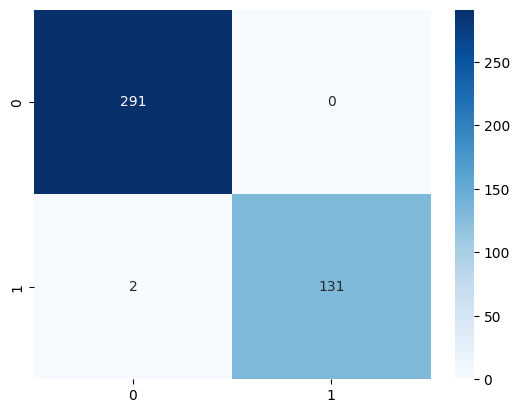

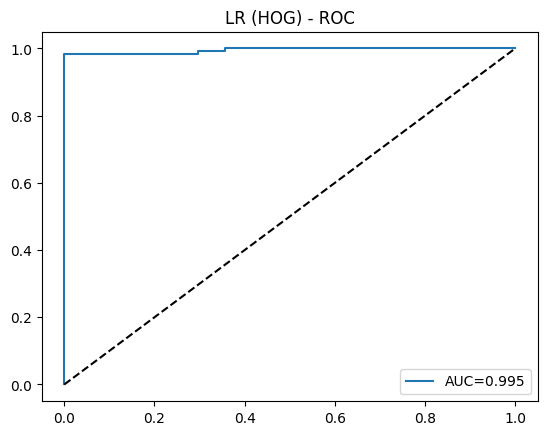

In [30]:
X_train, X_test, y_train, y_test = split_data(hog_X, hog_y)
X_train_s, X_test_s = scale(X_train, X_test)
lr = LogisticRegression(max_iter=2000)
lr.fit(X_train_s, y_train)

y_pred_train = lr.predict(X_train_s)

train_accuracy = accuracy_score(y_train, y_pred_train)
train_precision = precision_score(y_train, y_pred_train)
train_recall = recall_score(y_train, y_pred_train)
train_f1 = f1_score(y_train, y_pred_train)

print("🔹 TRAINING METRICS")
print("Accuracy:", train_accuracy)
print("Precision:", train_precision)
print("Recall:", train_recall)
print("F1-Score:", train_f1)
print("-" * 60)

y_pred_test = lr.predict(X_test_s)

test_accuracy = accuracy_score(y_test, y_pred_test)
test_precision = precision_score(y_test, y_pred_test)
test_recall = recall_score(y_test, y_pred_test)
test_f1 = f1_score(y_test, y_pred_test)

print("🔹 TESTING METRICS")
print("Accuracy:", test_accuracy)
print("Precision:", test_precision)
print("Recall:", test_recall)
print("F1-Score:", test_f1)
print("-" * 60)


print("\n🔹 Classification Report:")
print(classification_report(y_test, y_pred_test))

cm = confusion_matrix(y_test, y_pred_test)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.show()

y_prob = lr.predict_proba(X_test_s)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC={roc_auc:.3f}")
plt.plot([0,1], [0,1], 'k--')
plt.title("LR (HOG) - ROC")
plt.legend()
plt.show()

# Logistic Regression (PCA)
* LR usually performs better on PCA as features are lower dimensional and independent

🔹 TRAINING METRICS
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-Score: 1.0
------------------------------------------------------------
🔹 TESTING METRICS
Accuracy: 0.9976415094339622
Precision: 0.9925373134328358
Recall: 1.0
F1-Score: 0.9962546816479401
------------------------------------------------------------

🔹 Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       291
           1       0.99      1.00      1.00       133

    accuracy                           1.00       424
   macro avg       1.00      1.00      1.00       424
weighted avg       1.00      1.00      1.00       424



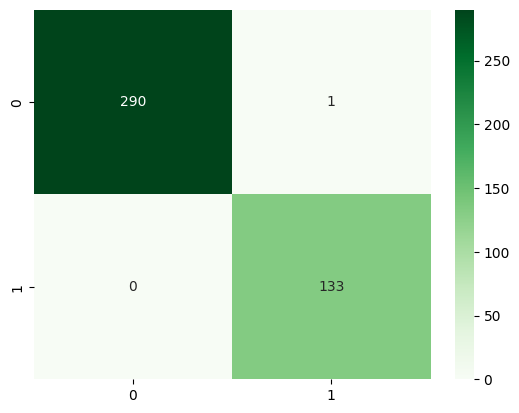

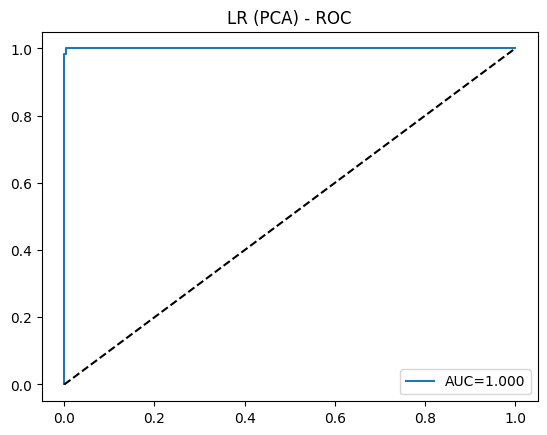

In [31]:
X_train, X_test, y_train, y_test = split_data(pca_X, pca_y)
X_train_s, X_test_s = scale(X_train, X_test)
lr = LogisticRegression(max_iter=2000)
lr.fit(X_train_s, y_train)

y_pred_train = lr.predict(X_train_s)

train_accuracy = accuracy_score(y_train, y_pred_train)
train_precision = precision_score(y_train, y_pred_train)
train_recall = recall_score(y_train, y_pred_train)
train_f1 = f1_score(y_train, y_pred_train)

print("🔹 TRAINING METRICS")
print("Accuracy:", train_accuracy)
print("Precision:", train_precision)
print("Recall:", train_recall)
print("F1-Score:", train_f1)
print("-" * 60)

y_pred_test = lr.predict(X_test_s)

test_accuracy = accuracy_score(y_test, y_pred_test)
test_precision = precision_score(y_test, y_pred_test)
test_recall = recall_score(y_test, y_pred_test)
test_f1 = f1_score(y_test, y_pred_test)

print("🔹 TESTING METRICS")
print("Accuracy:", test_accuracy)
print("Precision:", test_precision)
print("Recall:", test_recall)
print("F1-Score:", test_f1)
print("-" * 60)

print("\n🔹 Classification Report:")
print(classification_report(y_test, y_pred_test))

cm = confusion_matrix(y_test, y_pred_test)
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")
plt.show()

y_prob = lr.predict_proba(X_test_s)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC={roc_auc:.3f}")
plt.plot([0,1], [0,1], 'k--')
plt.title("LR (PCA) - ROC")
plt.legend()
plt.show()


# Logistic Regression (RESNET)
* Gives best LR performance and will be close to RF model

🔹 TRAINING METRICS
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-Score: 1.0
------------------------------------------------------------
🔹 TESTING METRICS
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-Score: 1.0
------------------------------------------------------------

🔹 Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       291
           1       1.00      1.00      1.00       133

    accuracy                           1.00       424
   macro avg       1.00      1.00      1.00       424
weighted avg       1.00      1.00      1.00       424



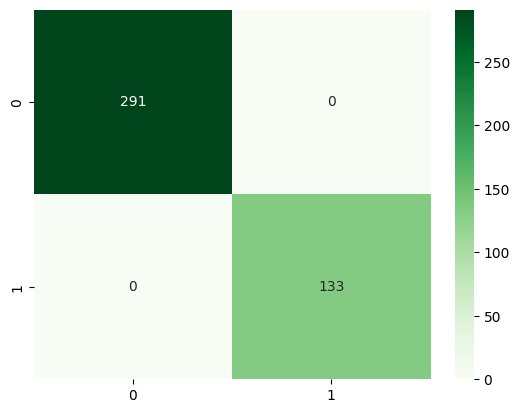

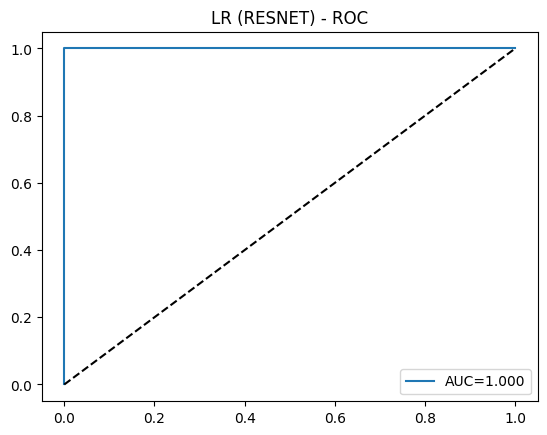

In [32]:
X_train, X_test, y_train, y_test = split_data(resnet_X, resnet_y)
X_train_s, X_test_s = scale(X_train, X_test)
lr = LogisticRegression(max_iter=3000)
lr.fit(X_train_s, y_train)

y_pred_train = lr.predict(X_train_s)

train_accuracy = accuracy_score(y_train, y_pred_train)
train_precision = precision_score(y_train, y_pred_train)
train_recall = recall_score(y_train, y_pred_train)
train_f1 = f1_score(y_train, y_pred_train)

print("🔹 TRAINING METRICS")
print("Accuracy:", train_accuracy)
print("Precision:", train_precision)
print("Recall:", train_recall)
print("F1-Score:", train_f1)
print("-" * 60)

y_pred_test = lr.predict(X_test_s)

test_accuracy = accuracy_score(y_test, y_pred_test)
test_precision = precision_score(y_test, y_pred_test)
test_recall = recall_score(y_test, y_pred_test)
test_f1 = f1_score(y_test, y_pred_test)

print("🔹 TESTING METRICS")
print("Accuracy:", test_accuracy)
print("Precision:", test_precision)
print("Recall:", test_recall)
print("F1-Score:", test_f1)
print("-" * 60)

print("\n🔹 Classification Report:")
print(classification_report(y_test, y_pred_test))

cm = confusion_matrix(y_test, y_pred_test)
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")
plt.show()

y_prob = lr.predict_proba(X_test_s)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC={roc_auc:.3f}")
plt.plot([0,1], [0,1], 'k--')
plt.title("LR (RESNET) - ROC")
plt.legend()
plt.show()